# Phase 3 — Synthèse : tableaux de résultats mis à jour (FD001 et FD002)

Objectif : rassembler tous les résultats des Phases 1, 2 et 3 dans deux tableaux finaux (un
par volet), pour avoir une vue d'ensemble unique à citer dans le mémoire. Aucun entraînement
ici — tous les chiffres viennent des notebooks précédents (déterministes, déjà exécutés) :

- FD001 : `04_baseline_fd001.ipynb`, `05_lstm_fd001.ipynb`, `13_transformer_fd001.ipynb`.
- FD002 : `11_fd002_ablation_regime.ipynb` (variante par régime), `14_transformer_fd002.ipynb`.

Critère « fait » (plan d'exécution, Phase 3) : tableaux de résultats des phases 1 et 2 mis à jour.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

fd001_results = pd.DataFrame([
    {"modèle": "Régression linéaire", "RMSE_val": 21.536573, "score_asymétrique_val": 77665.928021, "RMSE_test": 17.767336},
    {"modèle": "Forêt aléatoire", "RMSE_val": 17.899715, "score_asymétrique_val": 29640.942003, "RMSE_test": 17.869847},
    {"modèle": "LSTM", "RMSE_val": 13.088298, "score_asymétrique_val": 12245.140782, "RMSE_test": 12.225107},
    {"modèle": "Transformer", "RMSE_val": 13.167391, "score_asymétrique_val": 11923.526820, "RMSE_test": None},
])
fd001_results

,modèle,RMSE_val,score_asymétrique_val,RMSE_test
0,Régression linéaire,21.536573,77665.928021,17.767336
1,Forêt aléatoire,17.899715,29640.942003,17.869847
2,LSTM,13.088298,12245.140782,12.225107
3,Transformer,13.167391,11923.526820,NaN


**Pourquoi le Transformer n'a pas de `RMSE_test`** : le test FD001 a été ouvert une seule fois
dans `07_final_test_fd001.ipynb`, avant même que le Transformer n'existe. Le rouvrir maintenant
pour lui donner un score test irait à l'encontre de la règle du protocole — le Transformer
n'a donc, par construction, qu'un score de validation, pas de score test. C'est une limite
assumée à mentionner explicitement dans le mémoire, pas un oubli.

In [2]:
fd002_results = pd.DataFrame([
    {"modèle": "LSTM (régime-aware)", "RMSE_val": 15.074154, "score_asymétrique_val": 42105.297588},
    {"modèle": "Transformer (régime-aware)", "RMSE_val": 15.633626, "score_asymétrique_val": 50027.646116},
])
fd002_results

,modèle,RMSE_val,score_asymétrique_val
0,LSTM (régime-aware),15.074154,42105.297588
1,Transformer (régime-aware),15.633626,50027.646116


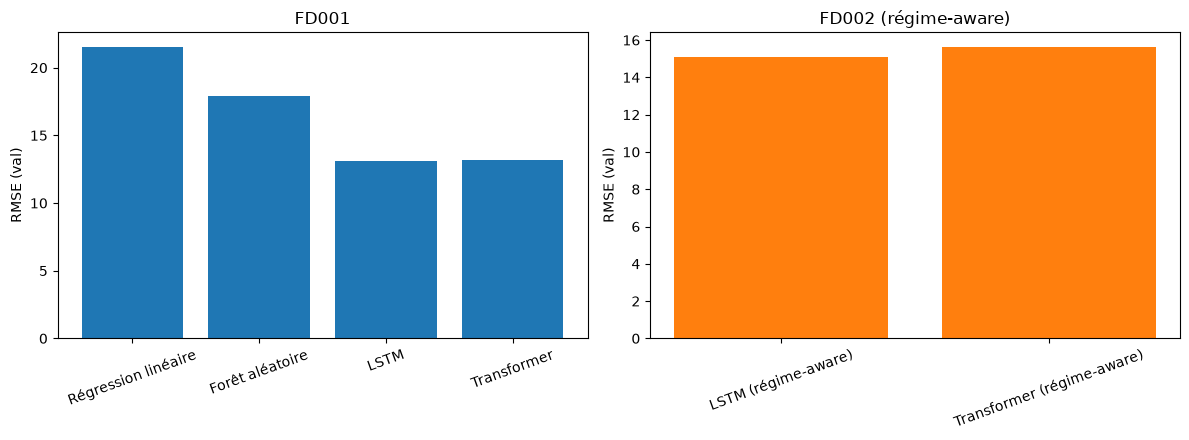

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(fd001_results["modèle"], fd001_results["RMSE_val"], color="tab:blue")
axes[0].set_title("FD001")
axes[0].set_ylabel("RMSE (val)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(fd002_results["modèle"], fd002_results["RMSE_val"], color="tab:orange")
axes[1].set_title("FD002 (régime-aware)")
axes[1].set_ylabel("RMSE (val)")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()

**Ce que montrent ces figures** : à gauche FD001, à droite FD002 — même échelle d'un jeu de
données à l'autre serait trompeuse (FD002 est un problème plus difficile, cf. `12_...ipynb`),
donc on compare les modèles à l'intérieur de chaque volet, pas les deux volets entre eux. Sur
FD001, LSTM et Transformer sont quasiment à égalité, tous deux loin devant les baselines. Sur
FD002, le LSTM garde un léger avantage sur le Transformer.

**Conclusion Phase 3** : un Transformer léger (1 couche, embedding positionnel appris) atteint
des performances comparables au LSTM sur FD001, mais ne le dépasse pas, et reste légèrement en
retrait sur FD002. Le gain du deep learning sur les baselines (H1) se confirme avec les deux
architectures ; en revanche, rien n'indique ici que l'attention apporte un avantage
supplémentaire sur ce problème et à cette échelle de données — un résultat à nuancer dans le
mémoire plutôt qu'un argument pour préférer systématiquement le Transformer.